In [1]:
!pip install rouge-score

In [2]:
import sys
!{sys.executable} -m pip install rouge-score

  Using cached rouge_score-0.1.2.tar.gz (17 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
 

# Import Libraries

In [3]:
import re
import string
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity

from rouge_score import rouge_scorer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Load the Articles

In [4]:
articles = {
    "technology": """
Artificial intelligence has moved from research labs into everyday life over the past decade.
Voice assistants answer questions in living rooms, recommendation engines shape what people watch
and buy, and machine learning models help doctors flag potential health risks earlier than before.
This rapid adoption has been driven largely by improvements in computing power, the availability
of large datasets, and advances in neural network architectures. However, the growth of AI has
also raised concerns about privacy, bias in automated decision-making, and the displacement of
certain jobs. Companies are now investing heavily in explainable AI, aiming to make model
decisions more transparent to regulators and end users alike. Governments across the world are
drafting new policies to govern how AI systems are built, tested, and deployed, particularly in
sensitive areas such as hiring, lending, and law enforcement. Researchers argue that responsible
innovation requires collaboration between engineers, ethicists, and policymakers rather than
leaving oversight solely to the companies building these systems. Meanwhile, smaller startups
continue to experiment with niche applications, from agricultural monitoring to personalized
education tools, showing that the impact of AI extends well beyond large technology firms.
Looking ahead, experts predict that the next wave of progress will focus on making models more
efficient, reducing their energy consumption, and building systems capable of reasoning over
longer and more complex tasks without constant human supervision.
""",

    "environment": """
Coral reefs around the world are facing unprecedented stress due to rising ocean temperatures and
acidification. Scientists have observed widespread bleaching events in recent years, where corals
expel the colorful algae living in their tissues, leaving behind a stark white skeleton and a
weakened ecosystem. Reefs support roughly a quarter of all marine species at some point in their
life cycle, making their decline a serious threat to biodiversity. Conservationists have begun
experimenting with coral nurseries, where fragments of heat-resistant coral species are grown in
controlled environments before being transplanted back onto damaged reefs. Some researchers are
also exploring selective breeding programs to produce corals that can better withstand warmer
water. Local communities that depend on reefs for tourism and fishing are increasingly involved in
restoration efforts, often working alongside marine biologists to monitor reef health over time.
International agreements have called for stronger protections of marine protected areas, though
enforcement remains inconsistent across regions. Without significant reductions in global carbon
emissions, however, many scientists warn that restoration efforts alone will not be enough to save
reefs in the long run, since rising temperatures continue to outpace the ability of ecosystems to
adapt naturally.
""",

    "health": """
Regular physical activity has long been associated with a reduced risk of chronic disease, but new
research suggests that even small amounts of movement throughout the day can have meaningful health
benefits. A recent study tracked thousands of adults using wearable activity monitors and found that
short bursts of brisk walking, sometimes lasting only a few minutes, were linked to lower rates of
cardiovascular disease over several years of follow-up. Public health officials have traditionally
recommended at least 150 minutes of moderate exercise per week, but the new findings suggest that
breaking activity into smaller chunks may be just as valuable for people who struggle to fit in
longer workout sessions. Researchers caution that the study is observational, meaning it cannot
prove cause and effect, but the results align with a growing body of evidence showing that any
movement is better than none. Experts recommend simple strategies such as taking the stairs, going
for short walks during work breaks, or doing light stretching between tasks. Beyond physical health,
these bursts of activity have also been linked to improved mood and better sleep quality. Health
organizations are now considering updating official guidelines to emphasize consistency and small,
sustainable habits rather than focusing solely on longer structured workouts.
""",

    "space": """
Astronomers have identified a new class of exoplanets that may offer fresh clues about how planetary
systems form around young stars. Using data from a space-based telescope, researchers detected these
planets by measuring tiny dips in starlight as the planets passed in front of their host stars. Several
of the newly discovered worlds orbit within their star's habitable zone, the region where conditions
might allow liquid water to exist on a planet's surface. Scientists caution that identifying a planet
in the habitable zone does not guarantee it can support life, since factors such as atmospheric
composition and magnetic field strength also play a critical role. Follow-up observations are planned
using more powerful telescopes capable of analyzing the chemical makeup of these planets' atmospheres.
Researchers are particularly interested in detecting gases such as oxygen and methane, which on Earth
are associated with biological activity. The discovery adds to a growing catalog of thousands of
confirmed exoplanets, reflecting rapid progress in observational astronomy over the past two decades.
Scientists say missions planned for the next decade will bring even greater precision, potentially
allowing researchers to study the surface conditions of distant worlds in unprecedented detail.
"""
}

for topic, text in articles.items():
    word_count = len(text.split())
    print(f"[{topic}] approx. word count: {word_count}")

[technology] approx. word count: 224
[environment] approx. word count: 194
[health] approx. word count: 206
[space] approx. word count: 193


# Text Cleaning & Preprocessing

In [5]:
def split_sentences(text):
    """Simple regex-based sentence splitter (avoids needing external NLTK downloads)."""
    text = re.sub(r"\s+", " ", text.strip())
    # Split on '.', '!', '?' followed by a space and a capital letter or end of string
    sentences = re.split(r"(?<=[.!?]) +(?=[A-Z(])", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    return sentences


STOPWORDS = set(ENGLISH_STOP_WORDS)

def clean_sentence(sentence):
    """Lowercase, strip punctuation/numbers, and remove stopwords - used ONLY for scoring."""
    s = sentence.lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [w for w in s.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)


# Preprocess each article: keep original sentences (for the final summary)
# alongside a cleaned version of each sentence (for scoring).
processed_articles = {}

for topic, text in articles.items():
    original_sentences = split_sentences(text)
    cleaned_sentences = [clean_sentence(s) for s in original_sentences]
    processed_articles[topic] = {
        "original_sentences": original_sentences,
        "cleaned_sentences": cleaned_sentences,
    }

# Preview for one article
sample_topic = "technology"
preview_df = pd.DataFrame({
    "original_sentence": processed_articles[sample_topic]["original_sentences"],
    "cleaned_sentence": processed_articles[sample_topic]["cleaned_sentences"],
})
preview_df

,original_sentence,cleaned_sentence
0,Artificial intelligence has moved from researc...,artificial intelligence moved research labs ev...
1,Voice assistants answer questions in living ro...,voice assistants answer questions living rooms...
2,This rapid adoption has been driven largely by...,rapid adoption driven largely improvements com...
3,"However, the growth of AI has also raised conc...",growth raised concerns privacy bias automated ...
4,Companies are now investing heavily in explain...,companies investing heavily explainable aiming...
5,Governments across the world are drafting new ...,governments world drafting new policies govern...
6,Researchers argue that responsible innovation ...,researchers argue responsible innovation requi...
7,"Meanwhile, smaller startups continue to experi...",smaller startups continue experiment niche app...
8,"Looking ahead, experts predict that the next w...",looking ahead experts predict wave progress fo...


# Extractive Summarization Techniques

# 1. Word-Frequency Based Summarization

In [6]:
def frequency_summarize(original_sentences, cleaned_sentences, num_sentences=3):
    word_freq = {}
    for sentence in cleaned_sentences:
        for word in sentence.split():
            word_freq[word] = word_freq.get(word, 0) + 1

    if not word_freq:
        return original_sentences[:num_sentences]

    max_freq = max(word_freq.values())
    normalized_freq = {word: freq / max_freq for word, freq in word_freq.items()}

    sentence_scores = []
    for i, sentence in enumerate(cleaned_sentences):
        words = sentence.split()
        if len(words) == 0:
            sentence_scores.append(0)
            continue
        score = sum(normalized_freq.get(w, 0) for w in words) / len(words)
        sentence_scores.append(score)

    top_indices = sorted(
        range(len(sentence_scores)), key=lambda i: sentence_scores[i], reverse=True
    )[:num_sentences]
    top_indices = sorted(top_indices)  # preserve original order

    summary = " ".join(original_sentences[i] for i in top_indices)
    return summary, sentence_scores

# 2. TF-IDF Based Summarization

In [7]:
def tfidf_summarize(original_sentences, cleaned_sentences, num_sentences=3):
    non_empty_idx = [i for i, s in enumerate(cleaned_sentences) if s.strip() != ""]
    if len(non_empty_idx) == 0:
        return " ".join(original_sentences[:num_sentences]), [0] * len(original_sentences)

    corpus = [cleaned_sentences[i] for i in non_empty_idx]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(corpus)

    # Score = sum of TF-IDF weights in that sentence
    scores_subset = np.asarray(tfidf_matrix.sum(axis=1)).flatten()

    sentence_scores = [0.0] * len(original_sentences)
    for idx, score in zip(non_empty_idx, scores_subset):
        sentence_scores[idx] = score

    top_indices = sorted(
        range(len(sentence_scores)), key=lambda i: sentence_scores[i], reverse=True
    )[:num_sentences]
    top_indices = sorted(top_indices)

    summary = " ".join(original_sentences[i] for i in top_indices)
    return summary, sentence_scores

# 3. TextRank (Graph-Based Summarization)

In [8]:
def textrank_summarize(original_sentences, cleaned_sentences, num_sentences=3):
    if len(original_sentences) <= num_sentences:
        return " ".join(original_sentences), [1.0] * len(original_sentences)

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(
        [s if s.strip() != "" else "empty" for s in cleaned_sentences]
    )

    similarity_matrix = cosine_similarity(tfidf_matrix)
    np.fill_diagonal(similarity_matrix, 0)  # a sentence shouldn't vote for itself

    graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(graph, max_iter=200)

    sentence_scores = [scores[i] for i in range(len(original_sentences))]

    top_indices = sorted(
        range(len(sentence_scores)), key=lambda i: sentence_scores[i], reverse=True
    )[:num_sentences]
    top_indices = sorted(top_indices)

    summary = " ".join(original_sentences[i] for i in top_indices)
    return summary, sentence_scores

# Generate Summaries for Each Article

In [9]:
NUM_SUMMARY_SENTENCES = 3

summaries = {}

for topic, data in processed_articles.items():
    orig = data["original_sentences"]
    clean = data["cleaned_sentences"]

    freq_summary, freq_scores = frequency_summarize(orig, clean, NUM_SUMMARY_SENTENCES)
    tfidf_summary, tfidf_scores = tfidf_summarize(orig, clean, NUM_SUMMARY_SENTENCES)
    tr_summary, tr_scores = textrank_summarize(orig, clean, NUM_SUMMARY_SENTENCES)

    summaries[topic] = {
        "original_text": " ".join(orig),
        "num_original_sentences": len(orig),
        "frequency_summary": freq_summary,
        "tfidf_summary": tfidf_summary,
        "textrank_summary": tr_summary,
    }

print("Summaries generated for all articles.")

Summaries generated for all articles.


# Compare Original Text vs. Generated Summaries

In [10]:
topic_to_inspect = "environment"
result = summaries[topic_to_inspect]

print("=" * 90)
print(f"TOPIC: {topic_to_inspect.upper()}")
print("=" * 90)

print(f"\n--- ORIGINAL ARTICLE ({result['num_original_sentences']} sentences) ---\n")
print(result["original_text"])

print(f"\n--- FREQUENCY-BASED SUMMARY ---\n")
print(result["frequency_summary"])

print(f"\n--- TF-IDF BASED SUMMARY ---\n")
print(result["tfidf_summary"])

print(f"\n--- TEXTRANK SUMMARY ---\n")
print(result["textrank_summary"])

TOPIC: ENVIRONMENT

--- ORIGINAL ARTICLE (8 sentences) ---

Coral reefs around the world are facing unprecedented stress due to rising ocean temperatures and acidification. Scientists have observed widespread bleaching events in recent years, where corals expel the colorful algae living in their tissues, leaving behind a stark white skeleton and a weakened ecosystem. Reefs support roughly a quarter of all marine species at some point in their life cycle, making their decline a serious threat to biodiversity. Conservationists have begun experimenting with coral nurseries, where fragments of heat-resistant coral species are grown in controlled environments before being transplanted back onto damaged reefs. Some researchers are also exploring selective breeding programs to produce corals that can better withstand warmer water. Local communities that depend on reefs for tourism and fishing are increasingly involved in restoration efforts, often working alongside marine biologists to monito

In [11]:
# Compression ratio: how much shorter is the summary compared to the original?
compression_rows = []

for topic, result in summaries.items():
    orig_words = len(result["original_text"].split())
    for method in ["frequency_summary", "tfidf_summary", "textrank_summary"]:
        summary_words = len(result[method].split())
        compression_ratio = 1 - (summary_words / orig_words)
        compression_rows.append({
            "topic": topic,
            "method": method.replace("_summary", ""),
            "original_words": orig_words,
            "summary_words": summary_words,
            "compression_ratio": round(compression_ratio, 3),
        })

compression_df = pd.DataFrame(compression_rows)
compression_df

,topic,method,original_words,summary_words,compression_ratio
0,technology,frequency,224,89,0.603
1,technology,tfidf,224,93,0.585
2,technology,textrank,224,83,0.629
3,environment,frequency,194,65,0.665
4,environment,tfidf,194,95,0.510
5,environment,textrank,194,80,0.588
6,health,frequency,206,88,0.573
7,health,tfidf,206,111,0.461
8,health,textrank,206,88,0.573
9,space,frequency,193,79,0.591


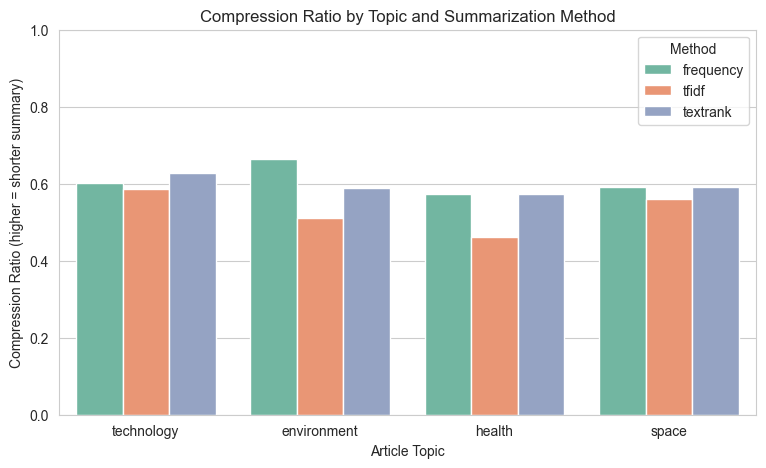

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=compression_df, x="topic", y="compression_ratio", hue="method", palette="Set2")
plt.title("Compression Ratio by Topic and Summarization Method")
plt.ylabel("Compression Ratio (higher = shorter summary)")
plt.xlabel("Article Topic")
plt.ylim(0, 1)
plt.legend(title="Method")
plt.show()

# Evaluate Summary Quality with ROUGE

In [13]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rouge_rows = []

for topic, result in summaries.items():
    reference_summary = result["textrank_summary"]  # baseline reference

    for method in ["frequency_summary", "tfidf_summary"]:
        candidate_summary = result[method]
        scores = scorer.score(reference_summary, candidate_summary)

        rouge_rows.append({
            "topic": topic,
            "method": method.replace("_summary", ""),
            "rouge1_f1": round(scores["rouge1"].fmeasure, 3),
            "rouge2_f1": round(scores["rouge2"].fmeasure, 3),
            "rougeL_f1": round(scores["rougeL"].fmeasure, 3),
        })

rouge_df = pd.DataFrame(rouge_rows)
rouge_df

,topic,method,rouge1_f1,rouge2_f1,rougeL_f1
0,technology,frequency,0.733,0.694,0.733
1,technology,tfidf,0.534,0.414,0.489
2,environment,frequency,0.626,0.552,0.571
3,environment,tfidf,0.557,0.437,0.511
4,health,frequency,1.000,1.000,1.000
5,health,tfidf,0.756,0.704,0.746
6,space,frequency,1.000,1.000,1.000
7,space,tfidf,0.710,0.647,0.651


,rouge1_f1,rouge2_f1,rougeL_f1
method,,,
frequency,0.840,0.812,0.826
tfidf,0.639,0.550,0.599


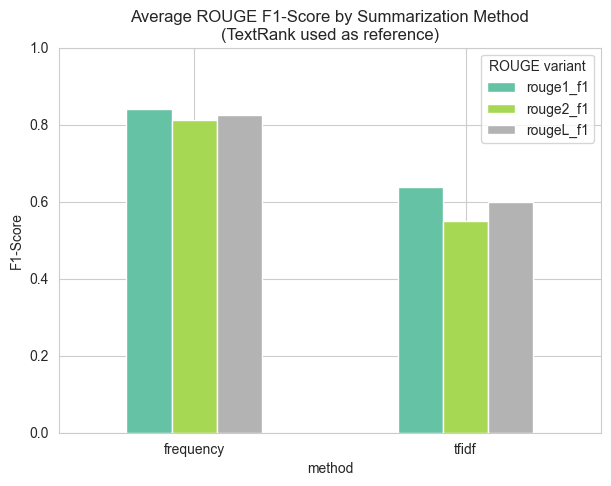

In [14]:
avg_rouge_df = rouge_df.groupby("method")[["rouge1_f1", "rouge2_f1", "rougeL_f1"]].mean().round(3)
display(avg_rouge_df)

avg_rouge_df.plot(kind="bar", figsize=(7, 5), colormap="Set2")
plt.title("Average ROUGE F1-Score by Summarization Method\n(TextRank used as reference)")
plt.ylabel("F1-Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="ROUGE variant")
plt.show()

# Content Preservation Score (TF-IDF Cosine Similarity)

In [15]:
def content_preservation_score(original_text, summary_text):
    vectorizer = TfidfVectorizer(stop_words="english")
    try:
        tfidf_matrix = vectorizer.fit_transform([original_text, summary_text])
        sim = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0]
    except ValueError:
        sim = 0.0
    return round(sim, 3)


preservation_rows = []

for topic, result in summaries.items():
    for method in ["frequency_summary", "tfidf_summary", "textrank_summary"]:
        sim_score = content_preservation_score(result["original_text"], result[method])
        preservation_rows.append({
            "topic": topic,
            "method": method.replace("_summary", ""),
            "content_preservation_score": sim_score,
        })

preservation_df = pd.DataFrame(preservation_rows)
preservation_df

,topic,method,content_preservation_score
0,technology,frequency,0.547
1,technology,tfidf,0.576
2,technology,textrank,0.504
3,environment,frequency,0.551
4,environment,tfidf,0.630
5,environment,textrank,0.595
6,health,frequency,0.648
7,health,tfidf,0.720
8,health,textrank,0.648
9,space,frequency,0.623


Average content preservation score by method:


method
frequency    0.592
textrank     0.592
tfidf        0.622
Name: content_preservation_score, dtype: float64

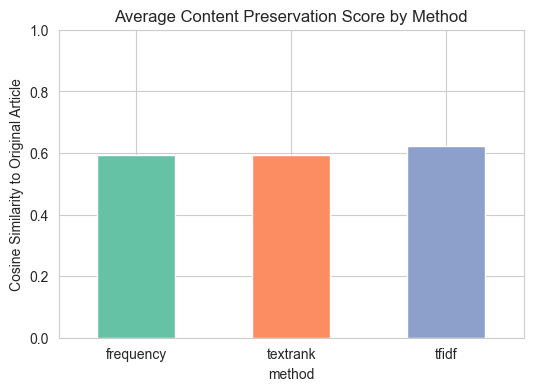

In [16]:
avg_preservation = preservation_df.groupby("method")["content_preservation_score"].mean().round(3)
print("Average content preservation score by method:")
display(avg_preservation)

avg_preservation.plot(kind="bar", figsize=(6, 4), color=["#66c2a5", "#fc8d62", "#8da0cb"])
plt.title("Average Content Preservation Score by Method")
plt.ylabel("Cosine Similarity to Original Article")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

# Try It Yourself: Summarize a Custom Article

In [17]:
custom_article = """
Remote work has reshaped how many companies think about office space, hiring, and daily
collaboration. Surveys conducted since 2020 consistently show that a majority of knowledge
workers prefer some form of hybrid schedule, splitting their time between home and the office.
Employers have responded in different ways: some have shrunk their office footprint entirely,
while others have redesigned spaces to prioritize collaboration rooms over rows of individual
desks. Critics argue that fully remote arrangements can weaken company culture and make
onboarding new employees more difficult, since informal mentorship often happens through casual,
in-person interactions. Proponents counter that remote work expands the talent pool beyond a
single city, allowing companies to hire skilled workers regardless of location, and that it can
improve employee satisfaction by cutting out long commutes. Several large firms have experimented
with four-day work weeks alongside remote policies, reporting productivity levels similar to or
better than traditional five-day schedules. As the debate continues, many organizations are
choosing to let individual teams decide what works best for them, rather than mandating a single
company-wide policy.
"""

custom_original_sentences = split_sentences(custom_article)
custom_cleaned_sentences = [clean_sentence(s) for s in custom_original_sentences]

freq_sum, _ = frequency_summarize(custom_original_sentences, custom_cleaned_sentences, num_sentences=3)
tfidf_sum, _ = tfidf_summarize(custom_original_sentences, custom_cleaned_sentences, num_sentences=3)
tr_sum, _ = textrank_summarize(custom_original_sentences, custom_cleaned_sentences, num_sentences=3)

print(f"Original sentence count: {len(custom_original_sentences)}\n")
print("--- Frequency-Based Summary ---")
print(freq_sum)
print("\n--- TF-IDF Summary ---")
print(tfidf_sum)
print("\n--- TextRank Summary ---")
print(tr_sum)

Original sentence count: 7

--- Frequency-Based Summary ---
Remote work has reshaped how many companies think about office space, hiring, and daily collaboration. Proponents counter that remote work expands the talent pool beyond a single city, allowing companies to hire skilled workers regardless of location, and that it can improve employee satisfaction by cutting out long commutes. Several large firms have experimented with four-day work weeks alongside remote policies, reporting productivity levels similar to or better than traditional five-day schedules.

--- TF-IDF Summary ---
Employers have responded in different ways: some have shrunk their office footprint entirely, while others have redesigned spaces to prioritize collaboration rooms over rows of individual desks. Critics argue that fully remote arrangements can weaken company culture and make onboarding new employees more difficult, since informal mentorship often happens through casual, in-person interactions. Proponents co